In [2]:
import pandas as pd
import numpy as np

In [68]:
df=pd.read_csv('heart.csv')
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
346,59,M,ASY,120,0,0,Normal,115,N,0.0,Flat,1
164,52,F,ATA,140,225,0,Normal,140,N,0.0,Up,0
29,51,M,ATA,125,188,0,Normal,145,N,0.0,Up,0
229,37,F,ASY,130,173,0,ST,184,N,0.0,Up,0
317,56,M,ASY,140,0,1,Normal,121,Y,1.8,Up,1


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sbn

<Axes: ylabel='MaxHR'>

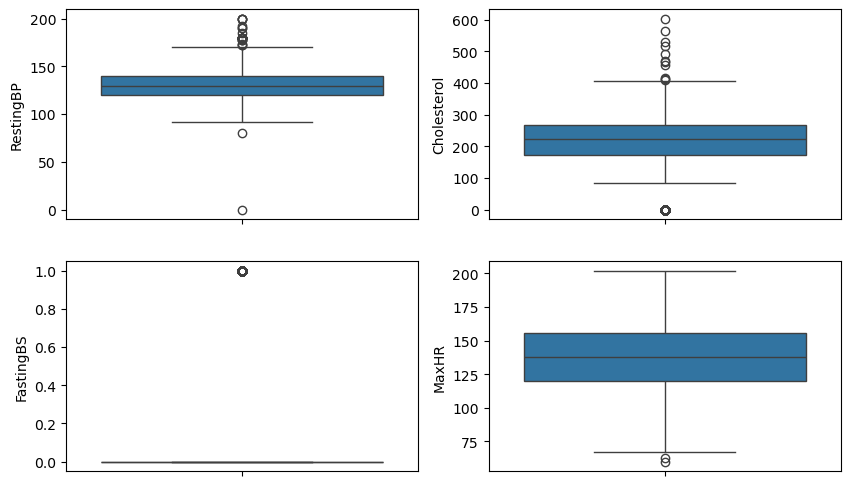

In [12]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sbn.boxplot(df['RestingBP'])
plt.subplot(2,2,2)
sbn.boxplot(df['Cholesterol'])
plt.subplot(2,2,3)
sbn.boxplot(df['FastingBS'])
plt.subplot(2,2,4)
sbn.boxplot(df['MaxHR'])

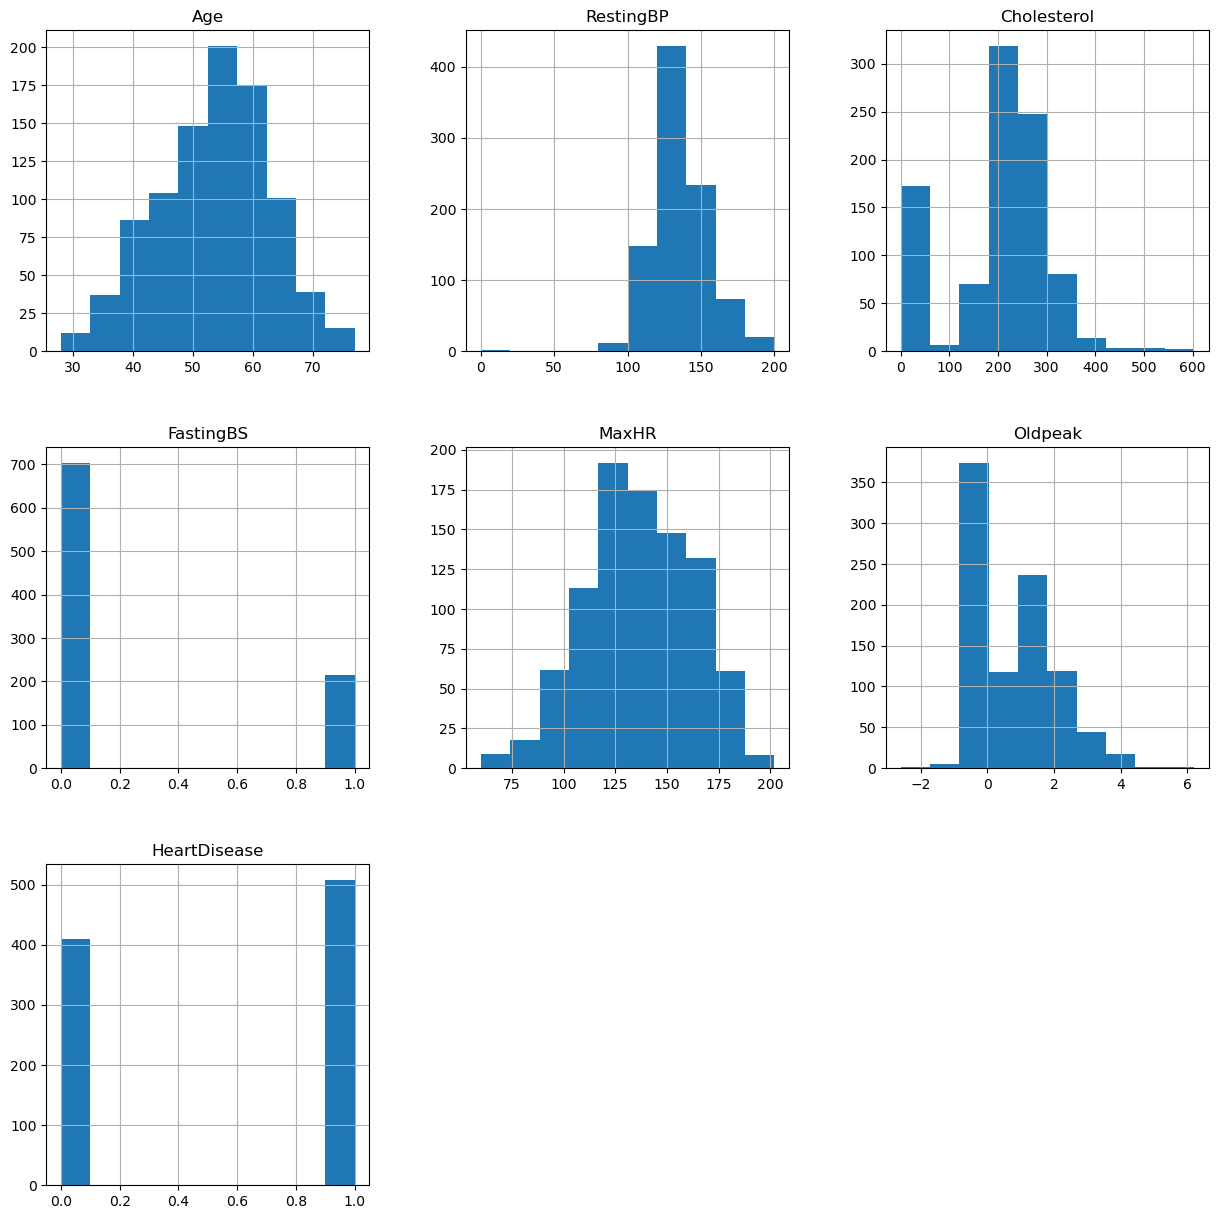

In [14]:
df.hist(figsize=(15,15));

### treating outliers using z score

In [21]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [70]:
df=df[df['RestingBP']<(3*df['RestingBP'].std()+df['RestingBP'].mean())]
df=df[df['MaxHR']<(3*df['MaxHR'].std()+df['MaxHR'].mean())]

In [29]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [72]:
#replacing cholestrol=0 with mean
df['Cholesterol']=df['Cholesterol'].apply(lambda x: df['Cholesterol'].mean() if x==0 else x )

In [74]:
print(df['ChestPainType'].value_counts())
print(df['RestingECG'].value_counts())
print(df['ST_Slope'].value_counts())
print(df['ExerciseAngina'].value_counts())


ChestPainType
ASY    492
NAP    202
ATA    171
TA      46
Name: count, dtype: int64
RestingECG
Normal    549
LVH       185
ST        177
Name: count, dtype: int64
ST_Slope
Flat    457
Up      393
Down     61
Name: count, dtype: int64
ExerciseAngina
N    544
Y    367
Name: count, dtype: int64


In [76]:
df['Sex']=df['Sex'].apply(lambda x: 0 if x=='F' else 1)

In [78]:
df['RestingECG']=df['RestingECG'].apply(lambda x: 0 if x=='Normal' else(1 if x=='LVH' else 2))

In [80]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289.0,0,0,172,N,0.0,Up,0
1,49,0,NAP,160,180.0,0,0,156,N,1.0,Flat,1
2,37,1,ATA,130,283.0,0,2,98,N,0.0,Up,0
3,48,0,ASY,138,214.0,0,0,108,Y,1.5,Flat,1
4,54,1,NAP,150,195.0,0,0,122,N,0.0,Up,0


In [82]:
df['ExerciseAngina']=df['ExerciseAngina'].apply(lambda x: 0 if x=='N' else 1)
df['ST_Slope']=df['ST_Slope'].apply(lambda x: 0 if x=='Flat' else(1 if x=='Up' else -1))

In [89]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289.0,0,0,172,0,0.0,1,0
1,49,0,NAP,160,180.0,0,0,156,0,1.0,0,1
2,37,1,ATA,130,283.0,0,2,98,0,0.0,1,0
3,48,0,ASY,138,214.0,0,0,108,1,1.5,0,1
4,54,1,NAP,150,195.0,0,0,122,0,0.0,1,0


In [93]:
## one hot encoding for chest Pain type
dummies=pd.get_dummies(df['ChestPainType']).astype(int)

In [101]:
df1=pd.concat([df,dummies],axis=1)

In [107]:
# droping ChestPainType and ASY column to avoid dummy trap
df1=df1.drop(['ChestPainType','ASY'],axis=1)

In [109]:
Target=df1['HeartDisease']
X=df1.drop(['HeartDisease'],axis=1)

### Scaling the columns

In [127]:
from sklearn.preprocessing import StandardScaler

In [131]:
Scale= StandardScaler()
X_scale=Scale.fit_transform(X)

In [113]:
from sklearn.model_selection import train_test_split

In [133]:
X_train,X_test,Y_train,Y_test=train_test_split(X_scale,Target,test_size=0.2)

### BaggingClassifier with DecisionTreeClassifier

In [121]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [153]:
model=BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=100,
                       oob_score=True,
                       random_state=10,
                       max_samples=0.8)

In [135]:
model.fit(X_train,Y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:789: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:795: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  oob_score=True, random_state=10)

In [137]:
model.score(X_test,Y_test)

0.8360655737704918

In [145]:
from sklearn.model_selection import cross_val_score

In [155]:
cross_val_score(model,X_scale,Target,cv=5)

array([0.87431694, 0.82417582, 0.81868132, 0.82417582, 0.7032967 ])

### without Bagging DecisionTreeClassifier

In [139]:
model1=DecisionTreeClassifier()

In [141]:
model1.fit(X_train,Y_train)

DecisionTreeClassifier()

In [143]:
model1.score(X_test,Y_test)

0.7650273224043715

In [162]:
cross_val_score(model1,X_scale,Target,cv=5)

array([0.7704918 , 0.77472527, 0.79120879, 0.72527473, 0.65934066])

### using SVM with bagging classifier

In [165]:
from sklearn.svm import SVC

In [192]:
model2=BaggingClassifier(estimator=SVC(C=10,gamma='auto',kernel='linear'),n_estimators=50,oob_score=True,max_samples=0.8)

In [194]:
cross_val_score(model2,X_scale,Target,cv=5)

array([0.8579235 , 0.84615385, 0.82967033, 0.83516484, 0.74175824])

### without bagging SVM

In [196]:
model3=SVC(C=10,gamma='auto',kernel='linear')

In [198]:
cross_val_score(model3,X_scale,Target,cv=5)

array([0.87978142, 0.84065934, 0.82417582, 0.84065934, 0.74175824])

## Observations

### 1. Performance of DecisionTreeClassifier with and without Bagging:
- **With Bagging**:
  - Scores: `[0.874, 0.824, 0.819, 0.824, 0.703]`
  - Average: ≈ **0.81**
- **Without Bagging**:
  - Scores: `[0.770, 0.775, 0.791, 0.725, 0.659]`
  - Average: ≈ **0.744**

**Conclusion**:
- Bagging significantly improves the performance of the `DecisionTreeClassifier`.
- Decision trees, being high-variance models, benefit greatly from bagging as it reduces variance and provides more stable and reliable predictions.
- Bagging is especially useful for noisy or smatasets.

---

### 2. Performance of SVM with and without Bagging:
- **With Bagging**:
  - Scores: `[0.858, 0.846, 0.830, 0.835, 0.742]`
  - Average: ≈ **0.822**
- **Without Bagging**:
  - Scores: `[0.880, 0.841, 0.824, 0.841, 0.742]`
  - Average: ≈ **0.826**

**Conclusion**:
- The improvement with bagging is minimal for SVMs, and in some cases, performance is slightly better without bagging.
- SVMs are inherently low-variance models due to their reliance on margin maximization, so they don’t benefit significantly from variance reduction via bagging.
- The computational overhead of bagging may nottify its use for SVMs.

---

### 3. General Observations:
- **Effectiveness of Bagging Depends on the Base Model**:
  - Models like `DecisionTreeClassifier`, which are prone to high variance, benefit more from bagging.
  - Models like `SVM`, which are more robust to variance, show minimal improvement.
- **Bagging Reduces Overfitting**:
  - For `DecisionTreeClassifier`, bagging reduces overfitting by aggregating multiple models trained on different subsets of data, leading to better generalization.
- **Stability of Predictions**:
  - Bagging improves the stability of performance across cross-validation folds for models like `DecisionTreeClassifier`, aen in the more consistent scores.

---

### Recommendations:
1. **For High-Variance Models (e.g., DecisionTreeClassifier)**:
   - Use bagging to significantly improve performance and reduce overfitting.
   - Consider ensemble methods like Random Forests for even better results.

2. **For Low-Variance Models (e.g., SVM)**:
   - Bagging may not provide substantial benefits and can add unnecessary computational cost.
   - Instead, focus on optimizing hyperparameters (e.g., kernel, C, gamma) for better performance.

3. **Model Selection**:
   - If computational resources are limited, `SVM` without bagging might be more efficient for achieving comparable performance.
   - If variance reduction is critical (e.g., small datasets or noisy data), bagging with `DecisionTreeClassifier` is a better choice.

